# Step 6: Benchmark Models

## Objective

The objective of this notebook is to establish benchmark machine learning performance for the Bank Customer Churn prediction project. The cleaned dataset from Step 5 is used to train and evaluate several standard classification models.

This benchmark provides a baseline for later model improvement and optimization. The models evaluated in this notebook are:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

The target variable is `Exited`, where:

- `0` = customer stayed
- `1` = customer exited/churned


## 1. Import Libraries

The notebook uses pandas and NumPy for data handling, matplotlib and seaborn for visualization, and scikit-learn for model training and evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Notebook settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Cleaned Dataset

This notebook uses the cleaned dataset created during Step 5. The path logic below checks common locations so the notebook can run whether it is opened from the project root or from the `notebooks/` folder.

In [2]:
from pathlib import Path

possible_paths = [
    Path('customer_churn_cleaned.csv'),
    Path('data/customer_churn_cleaned.csv'),
    Path('../data/customer_churn_cleaned.csv'),
    Path('/mnt/data/customer_churn_cleaned.csv')
]

file_path = None
for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError('Could not find customer_churn_cleaned.csv. Place it in the project root or data/ folder.')

print(f'Loading dataset from: {file_path}')
df = pd.read_csv(file_path)

df.head()

Loading dataset from: customer_churn_cleaned.csv


,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,844,18,2,160980.03,145936.28,0,0,0,1
1,656,18,10,151762.74,127014.32,0,0,0,1
2,570,18,4,82767.42,71811.90,0,0,0,0
3,716,18,3,128743.80,197322.13,0,1,0,0
4,727,18,4,133550.67,46941.41,0,0,0,1


## 3. Dataset Review

Before modeling, verify the dataset shape, columns, missing values, and target variable distribution.

In [3]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.info()

Rows: 10000
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   EstimatedSalary    10000 non-null  float64
 5   Exited             10000 non-null  int64  
 6   Geography_Germany  10000 non-null  int64  
 7   Geography_Spain    10000 non-null  int64  
 8   Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


In [4]:
df.isnull().sum()

CreditScore          0
Age                  0
Tenure               0
Balance              0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64

In [5]:
target_counts = df['Exited'].value_counts().sort_index()
target_rates = df['Exited'].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({
    'count': target_counts,
    'rate': target_rates
})
summary.index = ['Stayed (0)', 'Exited (1)']
summary

,count,rate
Stayed (0),7963,0.7963
Exited (1),2037,0.2037


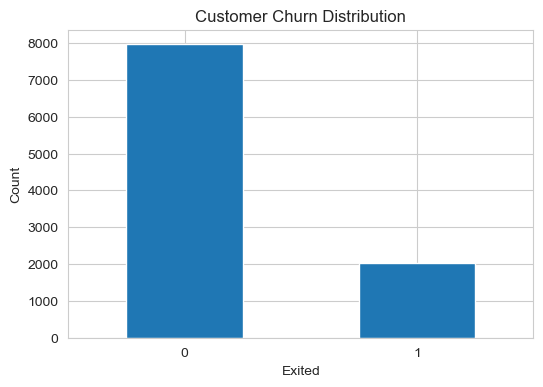

In [6]:
plt.figure(figsize=(6, 4))
df['Exited'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 4. Train/Test Split

The data is split into training and testing sets using stratification so the churn/non-churn class distribution is preserved in both sets.

In [7]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train churn rate: {y_train.mean():.3f}')
print(f'y_test churn rate: {y_test.mean():.3f}')

X_train shape: (8000, 8)
X_test shape: (2000, 8)
y_train churn rate: 0.204
y_test churn rate: 0.203


## 5. Helper Function for Model Evaluation

The function below trains a model, generates predictions, calculates common classification metrics, and prints a classification report.

In [8]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc
    }
    
    print(f'--- {model_name} ---')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
    disp.plot(values_format='d')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()
    
    return results, model

## 6. Benchmark Model 1: Logistic Regression

Logistic Regression is used as the first benchmark because it is simple, interpretable, and commonly used for binary classification problems. A `StandardScaler` is included because Logistic Regression is sensitive to feature scale.

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      1593
           1       0.45      0.12      0.19       407

    accuracy                           0.79      2000
   macro avg       0.63      0.54      0.54      2000
weighted avg       0.74      0.79      0.74      2000



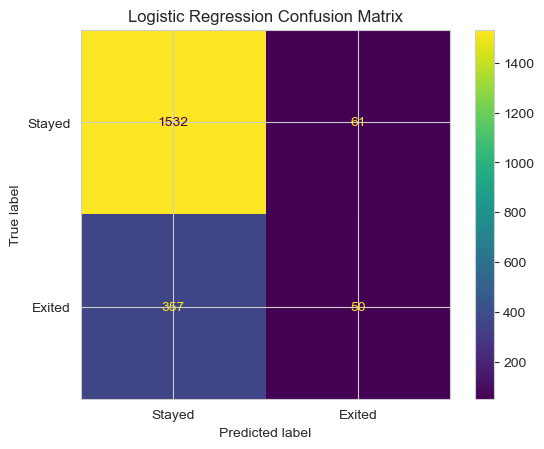

In [9]:
log_reg_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_results, log_reg_model = evaluate_model(
    'Logistic Regression',
    log_reg_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

## 7. Benchmark Model 2: Decision Tree

A Decision Tree is used as a second benchmark because it can capture nonlinear relationships and is relatively easy to interpret. The tree depth is limited to reduce overfitting.

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1593
           1       0.59      0.40      0.48       407

    accuracy                           0.82      2000
   macro avg       0.72      0.66      0.68      2000
weighted avg       0.80      0.82      0.81      2000



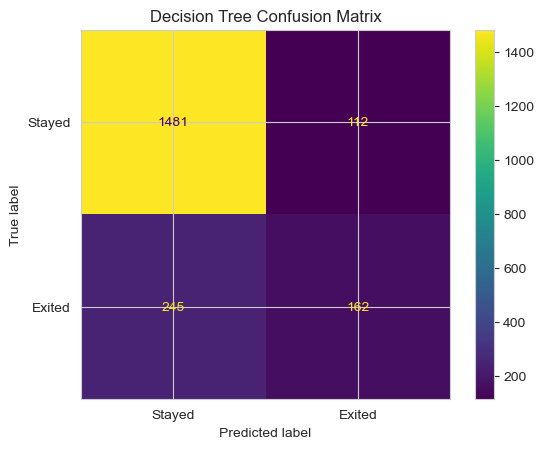

In [10]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_results, dt_model = evaluate_model(
    'Decision Tree',
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

## 8. Benchmark Model 3: Random Forest

Random Forest is used as a stronger ensemble benchmark. It combines many decision trees and typically performs well on structured tabular datasets.

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1593
           1       0.68      0.23      0.34       407

    accuracy                           0.82      2000
   macro avg       0.76      0.60      0.62      2000
weighted avg       0.80      0.82      0.78      2000



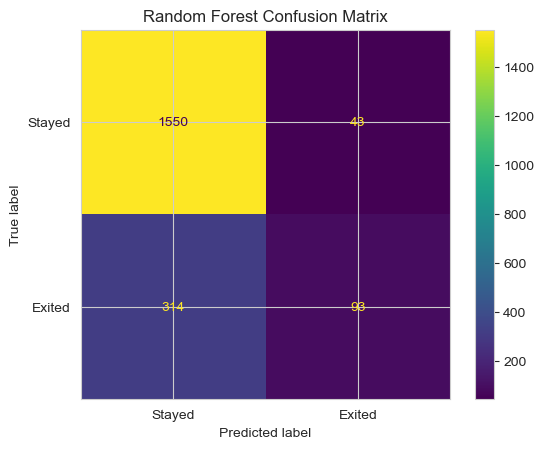

In [11]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_results, rf_model = evaluate_model(
    'Random Forest',
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

## 9. Benchmark Results Comparison

The results from each benchmark model are combined into a single table for comparison.

In [12]:
results_df = pd.DataFrame([
    log_reg_results,
    dt_results,
    rf_results
])

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df[metric_cols] = results_df[metric_cols].round(4)
results_df.sort_values(by='ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.8215,0.6838,0.2285,0.3425,0.7902
1,Decision Tree,0.8215,0.5912,0.3980,0.4758,0.7716
0,Logistic Regression,0.7910,0.4505,0.1229,0.1931,0.7529


<Figure size 1000x600 with 0 Axes>

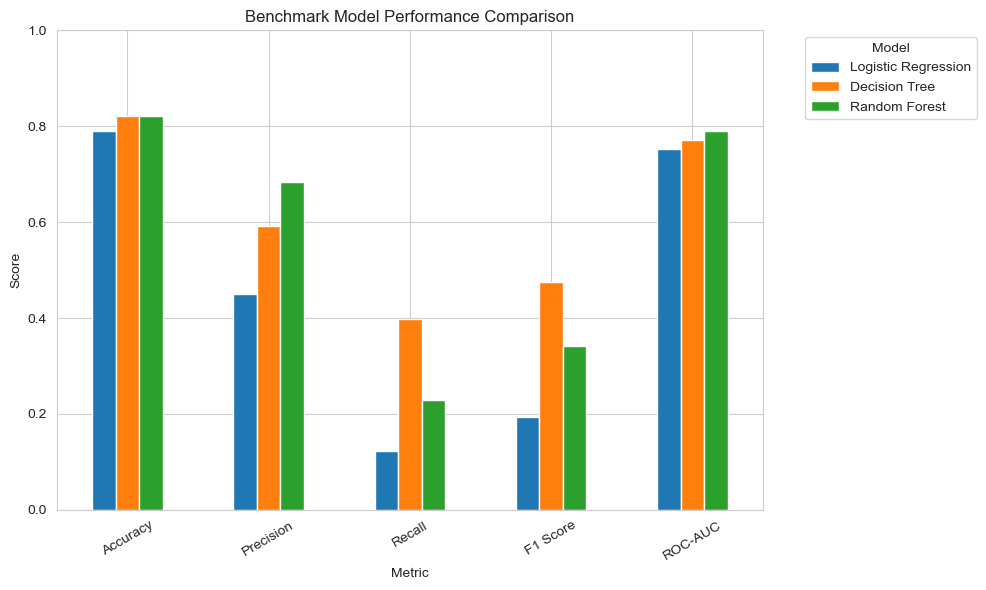

In [13]:
results_plot = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]

plt.figure(figsize=(10, 6))
results_plot.T.plot(kind='bar', figsize=(10, 6))
plt.title('Benchmark Model Performance Comparison')
plt.ylim(0, 1)
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. ROC Curve Comparison

ROC curves compare each model's ability to distinguish between customers who stayed and customers who exited.

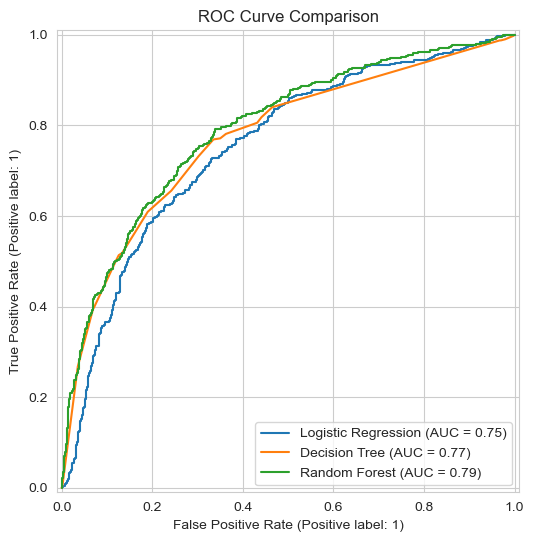

In [14]:
plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')

plt.title('ROC Curve Comparison')
plt.show()

## 11. Feature Importance

For the Random Forest benchmark model, feature importance can provide an initial view of which variables are most useful for predicting churn.

In [15]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
1,Age,0.499750
3,Balance,0.135018
0,CreditScore,0.104603
4,EstimatedSalary,0.093678
5,Geography_Germany,0.073723
2,Tenure,0.045001
7,Gender_Male,0.038192
6,Geography_Spain,0.010035


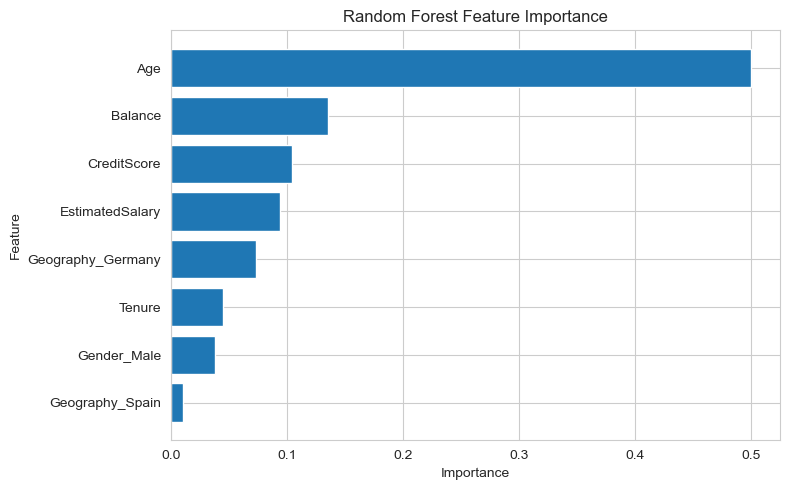

In [16]:
feature_importance_sorted = feature_importance.sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_sorted['Feature'], feature_importance_sorted['Importance'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 12. Save Benchmark Results

The benchmark results are saved to a CSV file so they can be referenced in later modeling and reporting steps.

In [17]:
output_paths = [
    Path('model_benchmark_results.csv'),
    Path('data/model_benchmark_results.csv'),
    Path('../data/model_benchmark_results.csv')
]

saved = False
for output_path in output_paths:
    try:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(output_path, index=False)
        print(f'Benchmark results saved to: {output_path}')
        saved = True
        break
    except Exception:
        continue

if not saved:
    print('Benchmark results were not saved, but results_df is available in memory.')

Benchmark results saved to: model_benchmark_results.csv


## 13. Benchmark Conclusions

This notebook established baseline performance for the customer churn prediction project using three standard classification models: Logistic Regression, Decision Tree, and Random Forest.

Key takeaways:

- Logistic Regression provides a simple and interpretable baseline.
- Decision Tree provides a nonlinear benchmark but can overfit if not constrained.
- Random Forest provides a stronger ensemble benchmark and also supports feature importance analysis.
- ROC-AUC, F1 Score, Precision, and Recall are more informative than accuracy alone because churn prediction often involves class imbalance.

These benchmark results will be used as the baseline for later model improvement, hyperparameter tuning, and final model selection.
